# Task 1: Data preparation

### 1A: Exploratory data analysis

In [49]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

In [7]:
df_mood = pd.read_csv('dataset_mood_smartphone.csv')
df_mood

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


In [15]:
print(df_mood.id.unique())

time_measures = []
for id in df_mood.id.unique():
    id_df = df_mood[df_mood.id == id]
    time_measures.append(len(id_df.time.unique()))

print(sorted(time_measures))

<ArrowStringArray>
['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08',
 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15', 'AS14.16', 'AS14.17',
 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.27',
 'AS14.28', 'AS14.29', 'AS14.30', 'AS14.31', 'AS14.32', 'AS14.33']
Length: 27, dtype: str
[2270, 3096, 3429, 6829, 8743, 10321, 10689, 10795, 11055, 12188, 13657, 13738, 13939, 14100, 15023, 15133, 15474, 15490, 15777, 16434, 16716, 16809, 17334, 18720, 18884, 20985, 21298]


In [13]:
df_mood.variable.unique()

<ArrowStringArray>
[                'mood',   'circumplex.arousal',   'circumplex.valence',
             'activity',               'screen',                 'call',
                  'sms',       'appCat.builtin', 'appCat.communication',
 'appCat.entertainment',       'appCat.finance',          'appCat.game',
        'appCat.office',         'appCat.other',        'appCat.social',
        'appCat.travel',       'appCat.unknown',     'appCat.utilities',
       'appCat.weather']
Length: 19, dtype: str

#### 1A.1 Ranges of values

In [17]:
for variable in df_mood.variable.unique():
    var_df = df_mood[df_mood.variable == variable]
    print(f'{variable}, min: {sorted(var_df.value)[0]}, max: {sorted(var_df.value)[-1]}')

mood, min: 1.0, max: 10.0
circumplex.arousal, min: -2.0, max: 2.0
circumplex.valence, min: -2.0, max: 2.0
activity, min: 0.0, max: 1.0
screen, min: 0.0350000858306885, max: 9867.00699996948
call, min: 1.0, max: 1.0
sms, min: 1.0, max: 1.0
appCat.builtin, min: -82798.871, max: 33960.246
appCat.communication, min: 0.006, max: 9830.777
appCat.entertainment, min: -0.011, max: 32148.677
appCat.finance, min: 0.131, max: 355.513
appCat.game, min: 1.003, max: 5491.793
appCat.office, min: 0.003, max: 32708.818
appCat.other, min: 0.014, max: 3892.038
appCat.social, min: 0.094, max: 30000.906
appCat.travel, min: 0.08, max: 10452.615
appCat.unknown, min: 0.111, max: 2239.937
appCat.utilities, min: 0.246, max: 1802.649
appCat.weather, min: 1.003, max: 344.863


#### 1A.2 Missing values

In [ ]:
# check whether there are any missing values in not 'value' column
df_mood.info()
# only in the last column, there are missing values
# 376912 - 376710 = 202 missing values

<class 'pandas.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  376912 non-null  int64  
 1   id          376912 non-null  str    
 2   time        376912 non-null  str    
 3   variable    376912 non-null  str    
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 29.8 MB


202

[np.int64(0), np.int64(46), np.int64(156), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
202


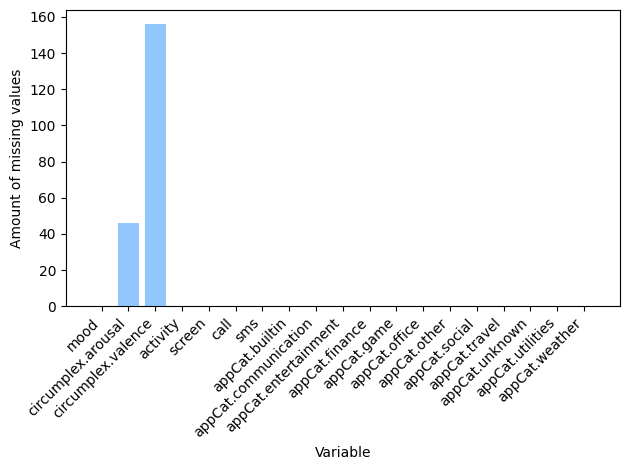

In [47]:
# missing values per variable
variables = df_mood.variable.unique()
missing = []
for variable in variables:
    var_df = df_mood[df_mood.variable == variable]
    missing.append(var_df["value"].isnull().sum())

# missing list adds up to 202:
print(missing)
print(sum(missing))

# plot distribution for this

fig, ax = plt.subplots()

ax.bar(variables, missing)
ax.set_ylabel("Amount of missing values")
ax.set_xlabel("Variable")
ax.tick_params("x", rotation = 45)

plt.setp(ax.get_xticklabels(), ha = "right")
plt.tight_layout()

    

202


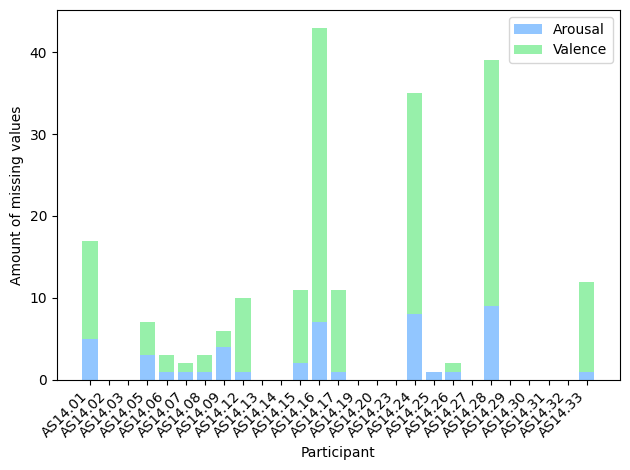

In [60]:
# missing values per participant
ids = df_mood.id.unique()
missing = []

missing_counts = {'Arousal': [], 'Valence': []}

for id in ids:
    #define df for this id
    id_df = df_mood[df_mood.id == id]

    # count missing values in arousal
    id_arouse_df = id_df[id_df.variable == 'circumplex.arousal']
    missing_counts['Arousal'].append(id_arouse_df["value"].isnull().sum())

    #count missing values in valence
    id_valence_df = id_df[id_df.variable == 'circumplex.valence']
    missing_counts['Valence'].append(id_valence_df['value'].isnull().sum())
   
# missing list adds up to 202:
print(sum(missing_counts['Arousal']) + sum(missing_counts['Valence']))

# plot distribution for this

fig, ax = plt.subplots()
bottom = np.zeros(len(ids))

for variable, counts in missing_counts.items():
    p = ax.bar(ids, counts, label = variable, bottom = bottom)
    bottom += counts
    # ax.bar_label(p, label_type = 'center')

# ax.bar(ids, missing)
ax.set_ylabel("Amount of missing values")
ax.set_xlabel("Participant")
ax.tick_params("x", rotation = 45)
ax.legend()

plt.setp(ax.get_xticklabels(), ha = "right")
plt.tight_layout()

#### 1A.3 Distribution of values

Text(0, 0.5, 'count')

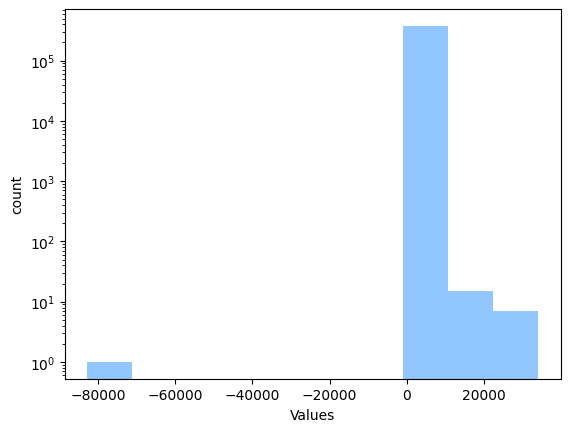

In [ ]:
# disribution of all values 

fig, ax = plt.subplots()
ax.hist(df_mood.value)
ax.set_yscale('log', base = 10)
ax.set_xlabel(f'Values')
ax.set_ylabel('count')

Text(0, 0.5, 'Count')

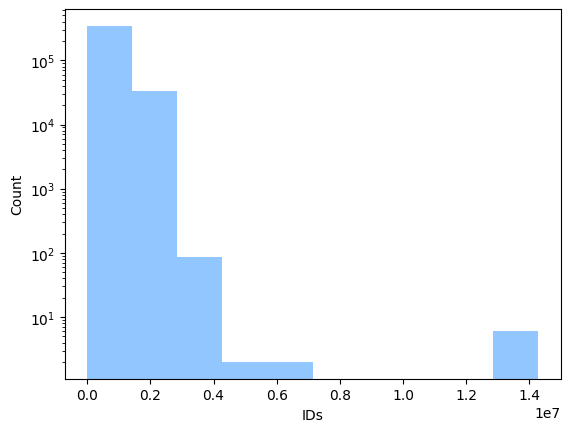

In [68]:
# distribution of ids

fig, ax = plt.subplots()
ax.hist(df_mood["Unnamed: 0"])
ax.set_yscale('log', base = 10)
ax.set_xlabel(f'IDs')
ax.set_ylabel('Count')

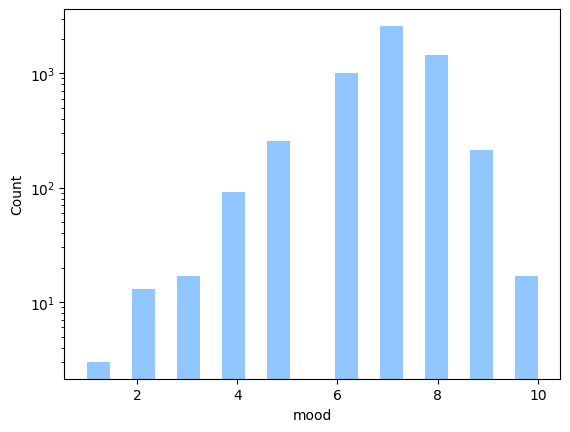

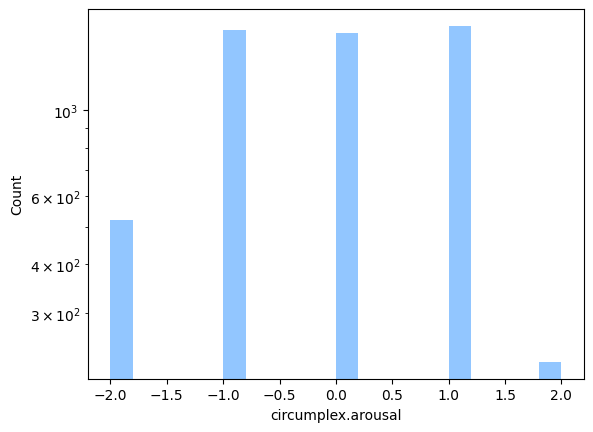

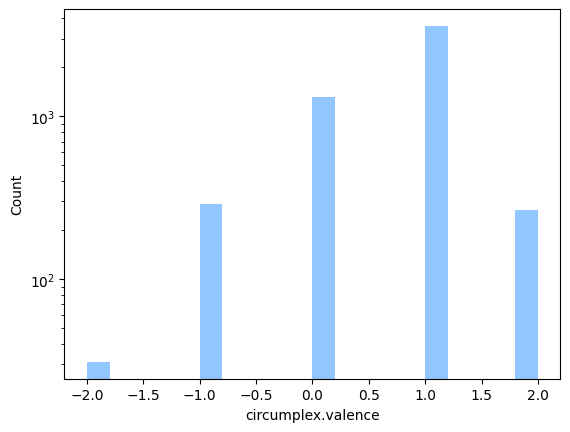

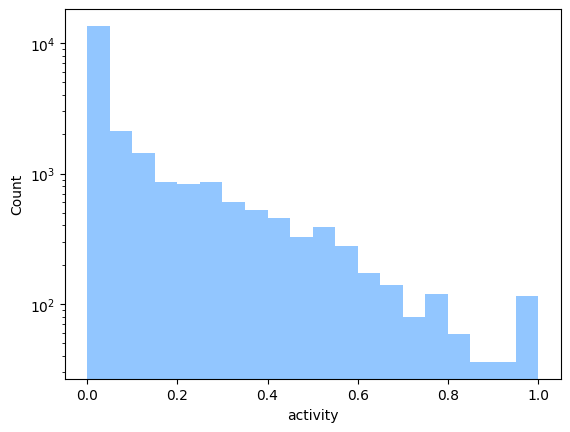

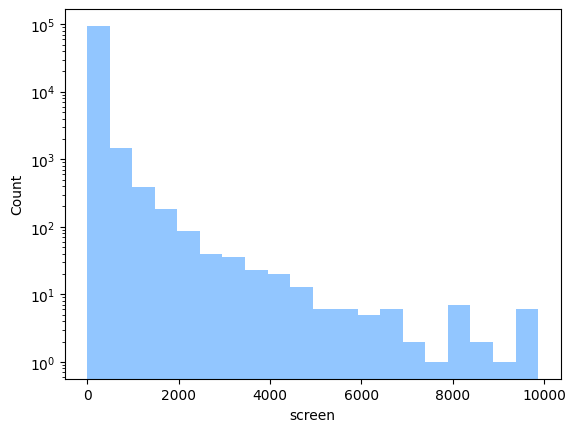

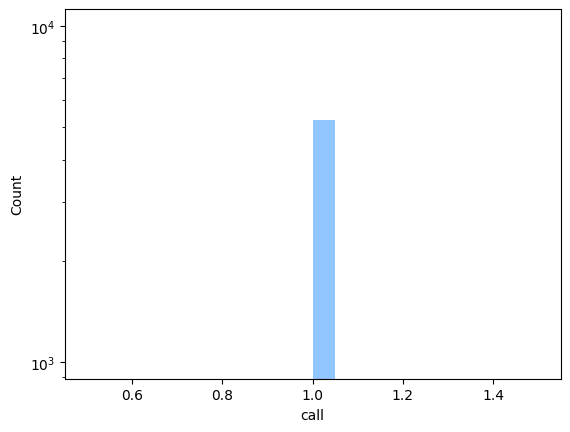

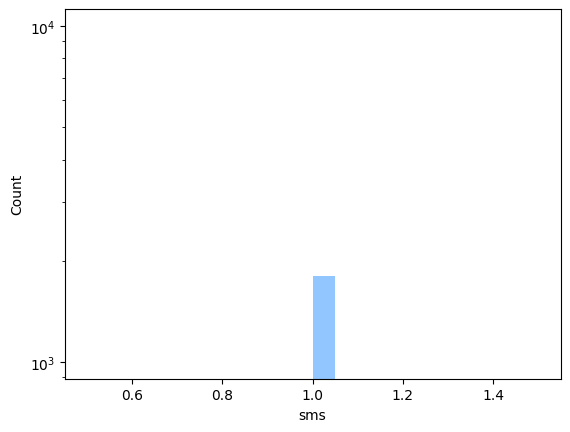

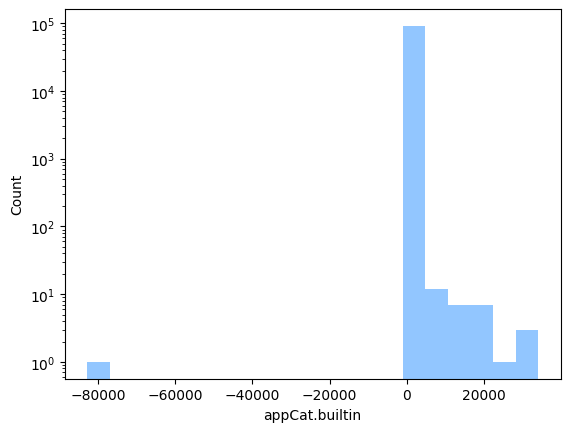

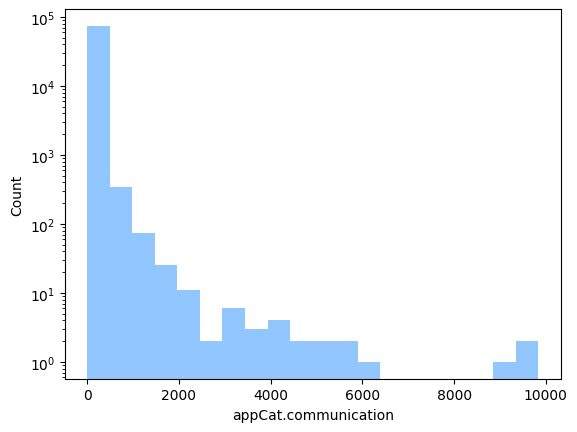

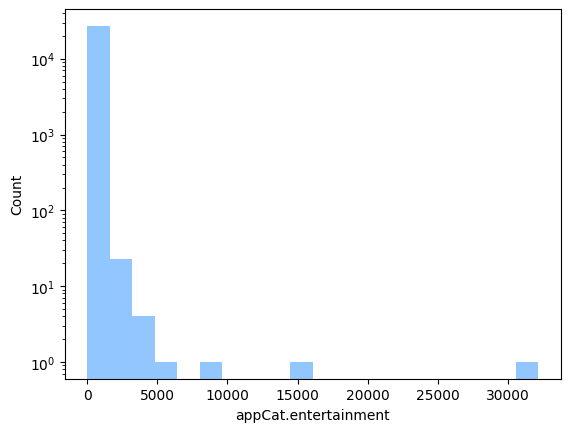

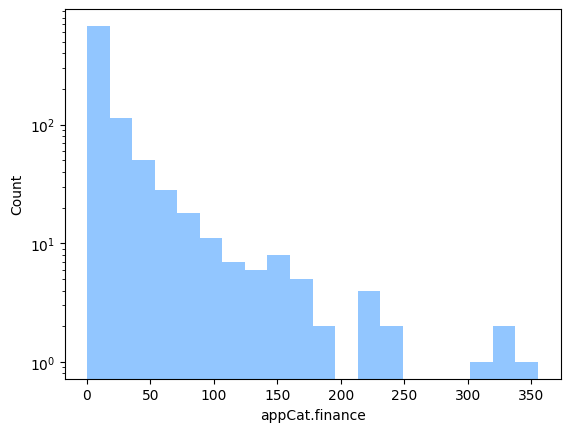

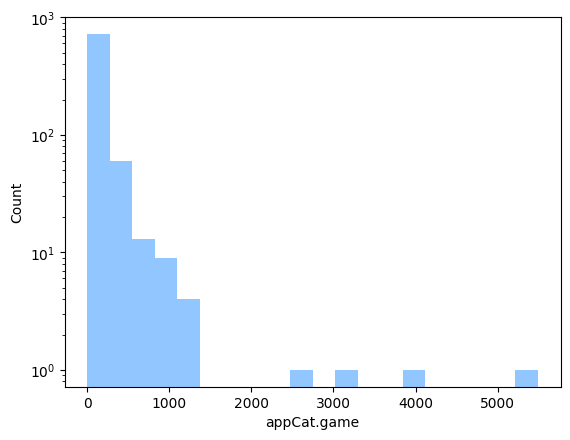

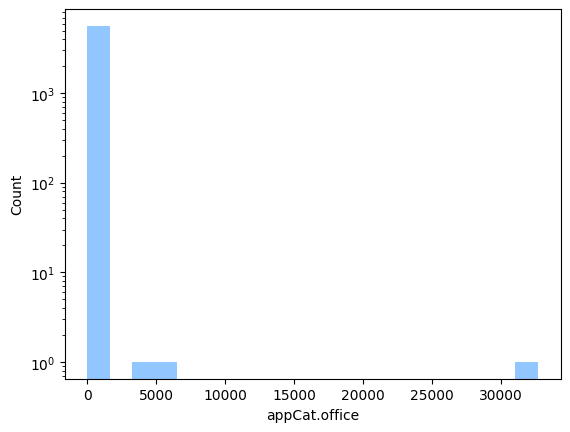

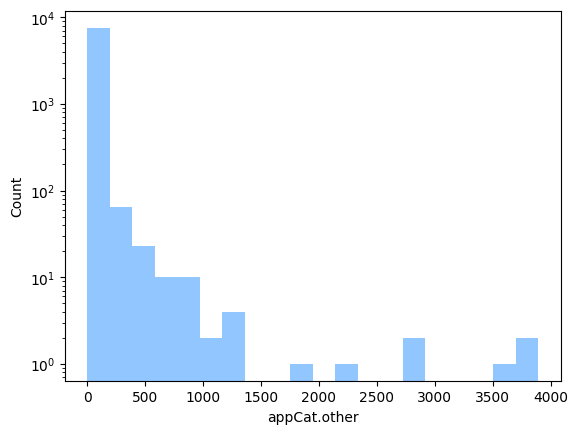

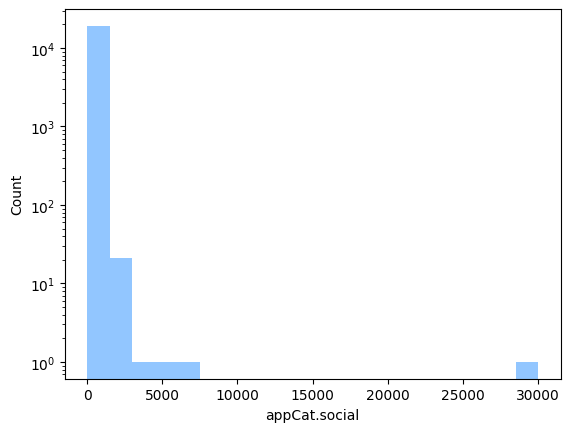

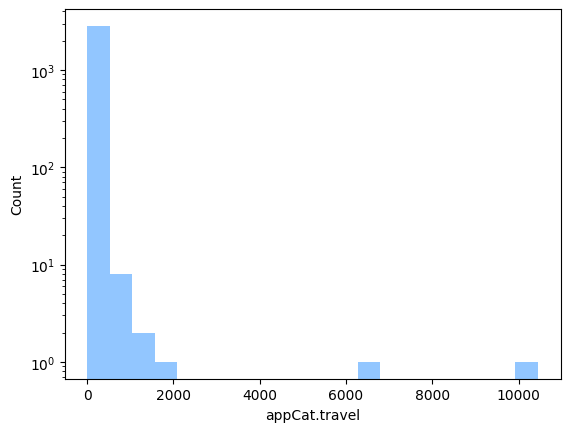

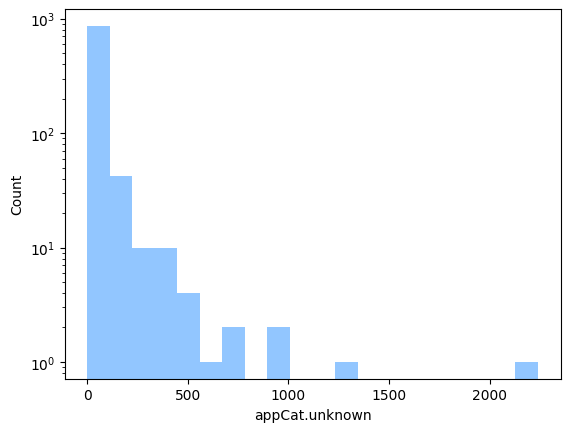

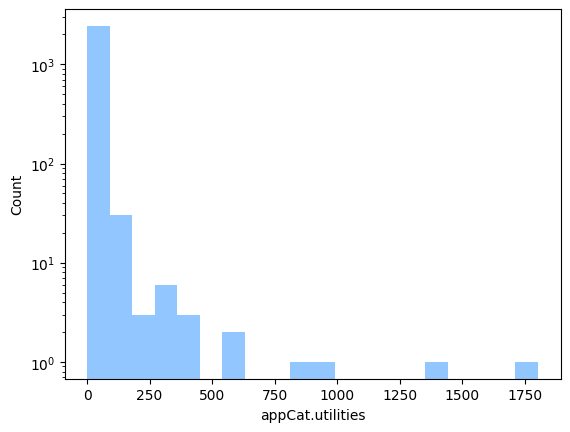

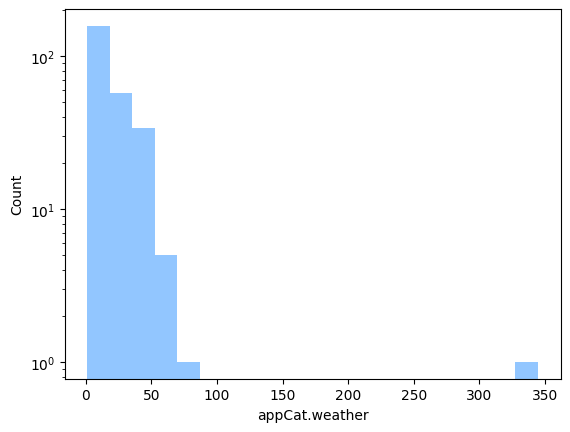

In [86]:
# distribution of values for each variable
for variable in df_mood.variable.unique():
    var_df = df_mood[df_mood.variable == variable]

    fig, ax = plt.subplots()
    ax.hist(var_df.value, bins = 20)
    ax.set_yscale('log', base = 10)
    ax.set_xlabel(f'{variable}')
    ax.set_ylabel('Count')

#### 1A.4 Relationships between attributes

#### 1A Summary

There are 276911 instances (without headers) in the raw data and 5 colomns
- 27 participants

Amount of measures in time differs for the participants. Ranging from 2270 times, to 21298 times

19 attributes in the 'variable' column